# Yield Curve Prediction
**By Aarav Singh, 24116003**

### Overview of Steps:

1. **Data Pre-processing**: Includes cleaning the data, handling outliers and time-series regularization.
2. **Implementing the Base CIR Model**: 1-Factor model calibration using Maximum Likelihood Estimation (MLE).
3. **Implementing a 3-Factor CIR Model**: Capturing Level, Slope, and Curvature dynamics to better fit the yield curve across multiple tenors.

### Step 1: Data Pre-processing
This section involves cleaning our dataset. It includes checking for duplicate records, extracting tenor information, checking for missing values, and handling outliers before modeling.

In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/train_data.csv')
test_df = pd.read_csv('/content/test_data.csv')

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df = train_df.set_index('Date')

test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df = test_df.set_index('Date')


#### Checking for Duplicates
We check for and remove any duplicate rows in both the training (`train_df`) and testing (`test_df`) datasets based on their index. Removing duplicates ensures our model is not biased by repeated observations.

In [ ]:
print("\n--- Checking for Duplicate Rows ---")

duplicates_train = train_df.index.duplicated().sum()
if duplicates_train > 0:
    print(f"Found {duplicates_train} duplicate rows in train_df. Dropping duplicates.")
    train_df = train_df[~train_df.index.duplicated(keep='first')]
    print(f"train_df shape after dropping duplicates: {train_df.shape}")
else:
    print("No duplicate rows found in train_df.")

duplicates_test = test_df.index.duplicated().sum()
if duplicates_test > 0:
    print(f"Found {duplicates_test} duplicate rows in test_df. Dropping duplicates.")
    test_df = test_df[~test_df.index.duplicated(keep='first')]
    print(f"test_df shape after dropping duplicates: {test_df.shape}")
else:
    print("No duplicate rows found in test_df.")


--- Checking for Duplicate Rows ---
No duplicate rows found in train_df.
No duplicate rows found in test_df.


#### Extracting Maturity Tenors
Here, we use a regular expression to extract the maturity tenors (in years) directly from the column names (e.g., extracting `0.25` from `ZC025YR`). These numeric tenors will be required later for curve fitting and model evaluation.

In [ ]:
import re

# Function to extract maturity tenor from column names
def extract_maturity_tenors(df):
    tenors = []
    for col in df.columns:
        match = re.search(r'ZC(\d+)YR', col)
        if match:
            year_str = match.group(1)
            # Convert '025' to 0.25, '050' to 0.5, '100' to 1.0, etc.
            if len(year_str) == 3 and year_str.startswith('0'):
                tenors.append(float(year_str) / 1000)
            else:
                tenors.append(float(year_str) / 100)
    return sorted(list(set(tenors)))

train_tenors = extract_maturity_tenors(train_df)
print(f"\nMaturity tenors for train_df (in years): {train_tenors}")

test_tenors = extract_maturity_tenors(test_df)
print(f"Maturity tenors for test_df (in years): {test_tenors}")


Maturity tenors for train_df (in years): [0.025, 0.05, 0.075, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
Maturity tenors for test_df (in years): [0.025, 0.05, 0.075, 1.0, 2.0]


#### Checking for Missing Values
We inspect both datasets for any missing (`NaN`) values across all columns. Identifying missing data early is crucial so we can properly impute or drop them before statistical modeling.

In [ ]:
print("\n--- Missing values in train_df ---\n")
print(train_df.isnull().sum())

print("\n--- Missing values in test_df ---\n")
print(test_df.isnull().sum())


--- Missing values in train_df ---

ZC025YR     0
ZC050YR     0
ZC075YR     0
ZC100YR     0
ZC200YR     0
ZC500YR     0
ZC1000YR    0
ZC2000YR    0
ZC3000YR    0
dtype: int64

--- Missing values in test_df ---

ZC025YR    0
ZC050YR    0
ZC075YR    0
ZC100YR    0
ZC200YR    0
dtype: int64


#### Looking for Outliers
We visualize the yield distributions across different maturities using box plots. This helps us visually identify extreme deviations or potential outliers in the interest rate data that could skew our calibration.

Generating box plots for Train Data yield data...


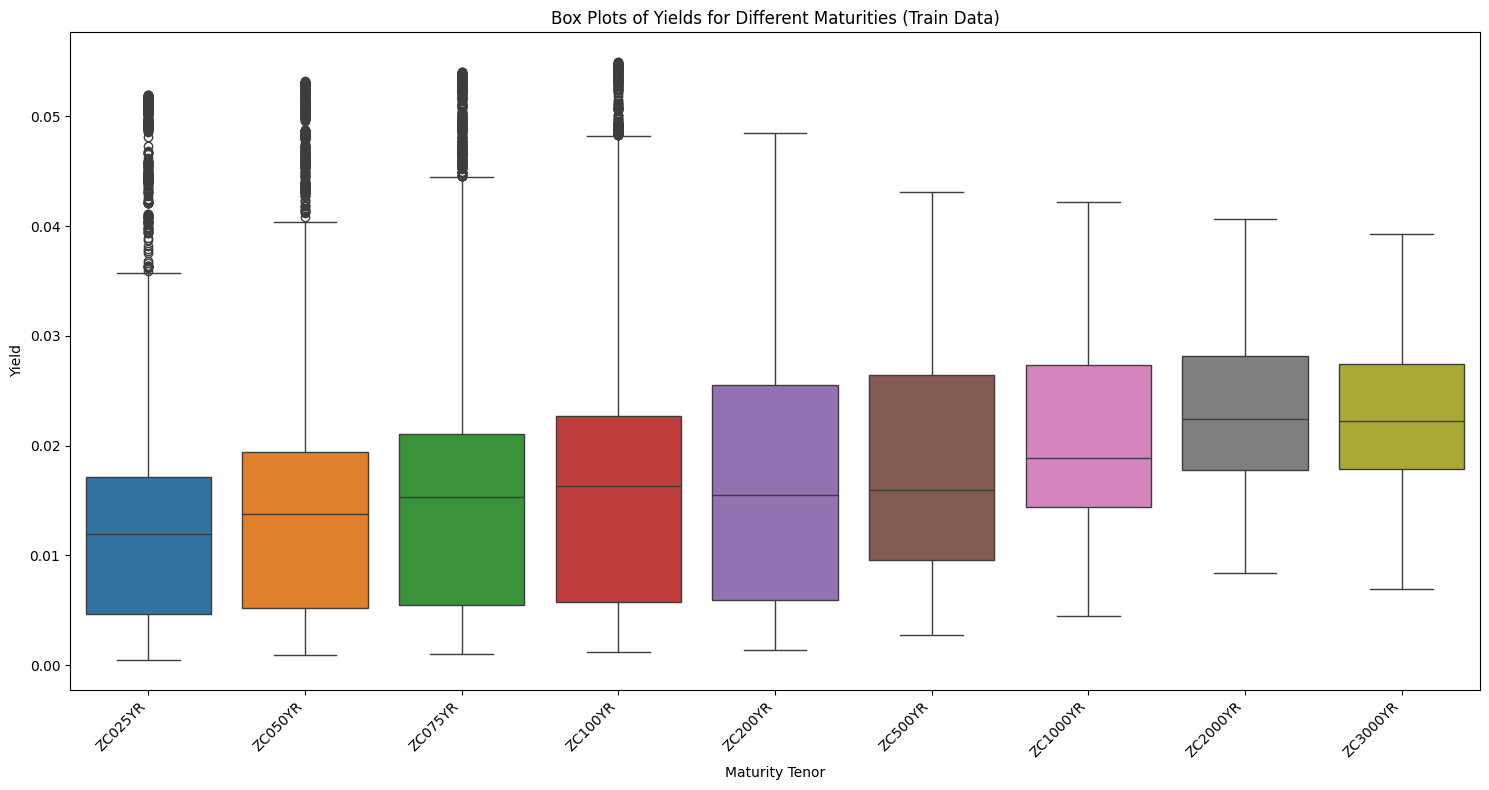

Generating box plots for Test Data yield data...


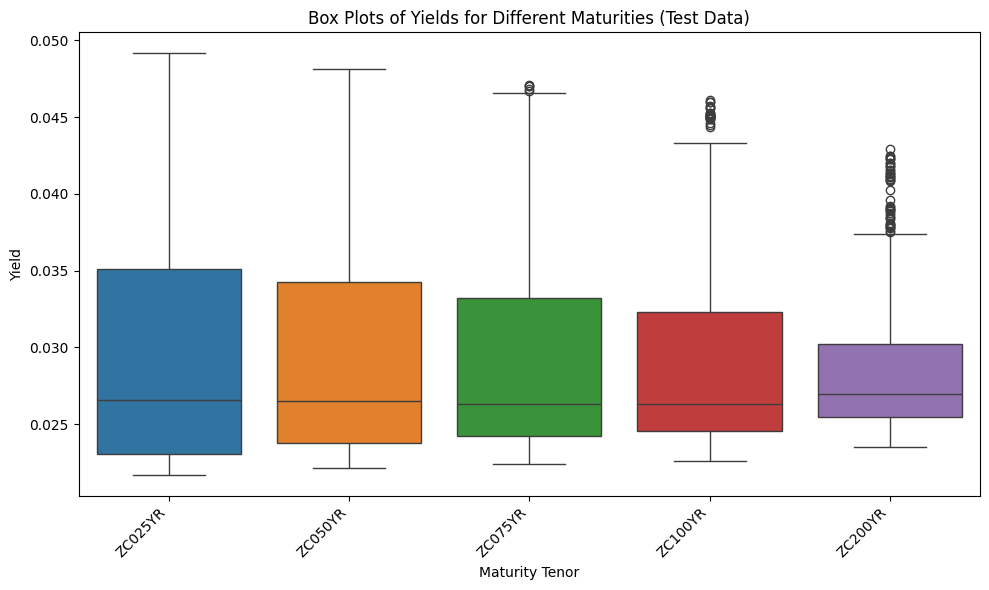

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_yield_boxplots(df, columns, dataset_name="Dataset", figsize=(12, 6)):

    print(f"Generating box plots for {dataset_name} yield data...")

    plt.figure(figsize=figsize)
    sns.boxplot(data=df[columns])

    plt.title(f'Box Plots of Yields for Different Maturities ({dataset_name})')
    plt.xlabel('Maturity Tenor')
    plt.ylabel('Yield')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

train_yield_cols = train_df.columns
test_yield_cols = test_df.columns

# Plot for Training Data
plot_yield_boxplots(
    train_df,
    train_yield_cols,
    dataset_name="Train Data",
    figsize=(15, 8)
)

# Plot for Testing Data
plot_yield_boxplots(
    test_df,
    test_yield_cols,
    dataset_name="Test Data",
    figsize=(10, 6)
)

#### Handling Outliers using Rolling MAD Filter
To handle the identified outliers without completely dropping time steps, we use a Rolling Median Absolute Deviation (MAD) filter. Data points falling beyond a specific threshold ($k$-MAD) from the rolling median are capped or interpolated, making the dataset robust to anomalous spikes.

The reason why winsorisation was not used is because it caps the outliers at a predetermined level. On the other hand, rolling mad filter caps it with respect to its neighbours which doesn't completely eliminate the volatility in financial markets.

In [ ]:
import numpy as np
import pandas as pd

def apply_rolling_mad_filter(df, columns, window_size=20, k_mad=3.5, dataset_name="Dataset"):

    print(f"\n--- Applying Rolling MAD Filter for {dataset_name} ---")

    df_cleaned = df.copy()
    replaced_counts = {}

    for col in columns:
        # Calculate the rolling median
        rolling_median = df_cleaned[col].rolling(window=window_size, min_periods=1).median()

        # Calculate rolling MAD (Median Absolute Deviation)
        rolling_mad = df_cleaned[col].rolling(window=window_size, min_periods=1).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )

        # Define dynamic outlier bounds based on the rolling MAD and scaling factor
        lower_bound = rolling_median - (k_mad * rolling_mad)
        upper_bound = rolling_median + (k_mad * rolling_mad)

        # Create boolean masks to flag values falling outside the bounds
        outlier_mask_lower = df_cleaned[col] < lower_bound
        outlier_mask_upper = df_cleaned[col] > upper_bound

        # Tally the number of outliers before making replacements
        replaced_count = (outlier_mask_lower | outlier_mask_upper).sum()
        replaced_counts[col] = replaced_count

        # Replace flagged outliers with the rolling median of that specific window
        df_cleaned.loc[outlier_mask_lower, col] = rolling_median[outlier_mask_lower]
        df_cleaned.loc[outlier_mask_upper, col] = rolling_median[outlier_mask_upper]

        print(f"Column '{col}': {replaced_count} outliers replaced.")

    return df_cleaned, replaced_counts


# Define parameters globally
window_size = 20
k_mad = 3.5

# Apply to training dataset
train_df, train_replaced_counts = apply_rolling_mad_filter(
    train_df,
    train_yield_cols,
    window_size=window_size,
    k_mad=k_mad,
    dataset_name="train_df"
)

# Apply to testing dataset
test_df, test_replaced_counts = apply_rolling_mad_filter(
    test_df,
    test_yield_cols,
    window_size=window_size,
    k_mad=k_mad,
    dataset_name="test_df"
)


--- Applying Rolling MAD Filter for train_df ---
Column 'ZC025YR': 386 outliers replaced.
Column 'ZC050YR': 407 outliers replaced.
Column 'ZC075YR': 364 outliers replaced.
Column 'ZC100YR': 340 outliers replaced.
Column 'ZC200YR': 288 outliers replaced.
Column 'ZC500YR': 287 outliers replaced.
Column 'ZC1000YR': 271 outliers replaced.
Column 'ZC2000YR': 253 outliers replaced.
Column 'ZC3000YR': 245 outliers replaced.

--- Applying Rolling MAD Filter for test_df ---
Column 'ZC025YR': 114 outliers replaced.
Column 'ZC050YR': 115 outliers replaced.
Column 'ZC075YR': 108 outliers replaced.
Column 'ZC100YR': 104 outliers replaced.
Column 'ZC200YR': 77 outliers replaced.


#### Resampling for Time Series Analysis
Since financial data might have irregular trading days (e.g., missing weekends or holidays), we resample the dataset to a daily frequency (`D`) and use linear interpolation to fill in any gaps. This ensures a continuous, evenly-spaced time series, which is required for Euler-Maruyama discretization later.

In [ ]:
print("--- Resampling train_df to daily frequency and interpolating missing values ---")
train_df_resampled = train_df.asfreq('D').interpolate(method='linear')
print(f"Original train_df shape: {train_df.shape}")
print(f"Resampled train_df shape: {train_df_resampled.shape}")
print("Head of resampled train_df:")
print(train_df_resampled.head())

print("\n--- Resampling test_df to daily frequency and interpolating missing values ---")
test_df_resampled = test_df.asfreq('D').interpolate(method='linear')
print(f"Original test_df shape: {test_df.shape}")
print(f"Resampled test_df shape: {test_df_resampled.shape}")
print("Head of resampled test_df:")
print(test_df_resampled.head())

# Update the original dataframes to reflect the resampled and interpolated data
train_df = train_df_resampled
test_df = test_df_resampled

--- Resampling train_df to daily frequency and interpolating missing values ---
Original train_df shape: (1976, 9)
Resampled train_df shape: (2900, 9)
Head of resampled train_df:
             ZC025YR   ZC050YR   ZC075YR   ZC100YR   ZC200YR   ZC500YR  \
Date                                                                     
2016-05-19  0.005283  0.005640  0.005846  0.006051  0.006146  0.007912   
2016-05-20  0.005286  0.005642  0.005848  0.006053  0.006176  0.007922   
2016-05-21  0.005286  0.005642  0.005848  0.006053  0.006189  0.007922   
2016-05-22  0.005286  0.005642  0.005848  0.006053  0.006202  0.007922   
2016-05-23  0.005286  0.005642  0.005848  0.006053  0.006215  0.007922   

            ZC1000YR  ZC2000YR  ZC3000YR  
Date                                      
2016-05-19  0.014099  0.021224  0.020492  
2016-05-20  0.014179  0.021353  0.020625  
2016-05-21  0.014229  0.021398  0.020667  
2016-05-22  0.014279  0.021443  0.020709  
2016-05-23  0.014329  0.021489  0.020751  



## Base CIR Model Implementation & Calibration

In this phase, we calibrate the Cox-Ingersoll-Ross (CIR) model parameters $(\kappa, \theta, \sigma)$ using Maximum Likelihood Estimation (MLE).

### 1. Discretization and the Time Step ($\Delta t$)

The true CIR model operates in continuous time, defined by the Stochastic Differential Equation (SDE):

$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

However, market data is discrete (recorded daily). So we discretize the SDE. Assuming 255 trading days in a typical financial year, the time elapsed between one daily observation and the next is:

$$\Delta t = \frac{1}{252}$$

### 2. Euler-Maruyama and the Gaussian Assumption

The Euler-Maruyama method approximates the change as:

$$r_{t+\Delta t} - r_t \approx \kappa(\theta - r_t)\Delta t + \sigma\sqrt{r_t}(W_{t+\Delta t} - W_t)$$

The term $(W_{t+\Delta t} - W_t)$ represents the increment of a standard Brownian motion, which is normally distributed with a mean of $0$ and a variance equal to $\Delta t$. We can rewrite it as $\sqrt{\Delta t}Z$, where $Z \sim \mathcal{N}(0, 1)$. Substituting this back gives the transition equation:

$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{r_t}\sqrt{\Delta t}Z$$

Given that $Z$ is normally distributed, and assuming the current rate $r_t$ is known, the next rate $r_{t+\Delta t}$ conditionally follows a Gaussian distribution. This defines our conditional mean ($\mu_t$) and variance ($v_t$):

* **Mean:** $\mu_t = r_t + \kappa(\theta - r_t)\Delta t$
* **Variance:** $v_t = \sigma^2 r_t \Delta t$

### 3. The PDF and Negative Log-Likelihood (NLL)

With $r_{t+\Delta t}$ conditionally following a Gaussian distribution, we use the standard Normal Probability Density Function (PDF) to calculate the likelihood of our observations:

$$f(r_{t+\Delta t} \mid r_t) = \frac{1}{\sqrt{2\pi v_t}} \exp\left(-\frac{(r_{t+\Delta t} - \mu_t)^2}{2v_t}\right)$$

To find the parameters that best fit the entire training dataset, we multiply the individual probabilities of every day-to-day transition to get the **Likelihood**. To prevent numerical underflow in computation, we take the natural logarithm, converting the product into a sum:

$$\mathcal{L} = \sum_{t=1}^{N-1} \left[ -\frac{1}{2}\ln(2\pi) - \frac{1}{2}\ln(v_t) - \frac{(r_{t+\Delta t} - \mu_t)^2}{2v_t} \right]$$

Optimization algorithms (like `scipy.optimize.minimize`) find the minimum of a function. Therefore, we multiply the log-likelihood by $-1$ to create the **Negative Log-Likelihood (NLL)**
$$\text{NLL

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Use ZC025YR (3-month) as the short-rate proxy
r = train_df['ZC025YR'].values
dt = 1/252.0  # Daily frequency

def cir_nll(params, r, dt):
    kappa, theta, sigma = params

    # Slice data for t and t+1
    r_t = r[:-1]
    r_next = r[1:]

    # Euler-Maruyama conditional mean and variance
    mu = r_t + kappa * (theta - r_t) * dt
    var = (sigma**2) * r_t * dt
    var = np.maximum(var, 1e-9)

    # Log-likelihood of normal distribution
    term1 = -0.5 * np.log(2 * np.pi * var)
    term2 = - ((r_next - mu)**2) / (2 * var)

    return -np.sum(term1 + term2) / len(r)

# Feller Condition: 2*kappa*theta >= sigma^2  => 2*kappa*theta - sigma^2 >= 0
cons = ({'type': 'ineq', 'fun': lambda x: 2 * x[0] * x[1] - x[2]**2})

# Parameters must be positive
bounds = [(1e-5, None), (1e-5, None), (1e-5, None)]

# 3. Initial Guess
initial_guess = [0.5, np.mean(r), 0.15]

# 4. Perform Optimization
result = minimize(
    cir_nll,
    initial_guess,
    args=(r, dt),
    method='SLSQP',
    bounds=bounds,
    constraints=cons,
    options={'maxiter': 2000, 'ftol': 1e-7}
)

# 5. Extract and Display Results
if result.success:
    kappa_opt, theta_opt, sigma_opt = result.x
    feller_val = 2 * kappa_opt * theta_opt - sigma_opt**2

    print("--- Calibrated CIR Parameters ---")
    print(f"Kappa (Mean Reversion Speed): {kappa_opt:.6f}")
    print(f"Theta (Long-term Mean):      {theta_opt:.6f}")
    print(f"Sigma (Volatility):           {sigma_opt:.6f}")
    print(f"Feller Condition Value:      {feller_val:.8f} (Must be >= 0)")
else:
    print("Optimization failed:", result.message)

--- Calibrated CIR Parameters ---
Kappa (Mean Reversion Speed): 0.001149
Theta (Long-term Mean):      1.708470
Sigma (Volatility):           0.048700
Feller Condition Value:      0.00155569 (Must be >= 0)


## Yield Curve Construction: The Affine Term Structure

### 1. The Bond Pricing Formula
In the CIR framework, the price of a zero-coupon bond $P(t, T)$ at time $t$ maturing at time $T$, where the time to maturity is $\tau = T - t$, is fundamentally defined as:

$$P(t,T) = A(\tau)e^{-B(\tau)r_t}$$

To calculate this, the mathematical derivations require computing two deterministic functions, $A(\tau)$ and $B(\tau)$, which depend entirely on the calibrated parameters $(\kappa, \theta, \sigma)$ and the time to maturity $\tau$.

### 2. The Auxiliary Variable ($\gamma$)
To simplify the complex differential equations that solve for $A(\tau)$ and $B(\tau)$, the code first calculates an auxiliary variable, $\gamma$:

$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

### 3. Calculating $B(\tau)$ and $A(\tau)$
With $\gamma$ established, we can define the specific shapes of our deterministic functions.

**The $B(\tau)$ Function:** This function captures the sensitivity of the bond's price to the current short rate $r_t$. It incorporates the speed of mean reversion ($\kappa$) and volatility ($\sigma$):

$$B(\tau) = \frac{2(e^{\gamma\tau} - 1)}{2\gamma + (\kappa + \gamma)(e^{\gamma\tau} - 1)}$$

**The $A(\tau)$ Function:**
This function acts as a scaling factor, accounting for the long-run mean ($\theta$) and the mathematical properties of the square-root diffusion process:

$$A(\tau) = \left( \frac{2\gamma e^{(\kappa + \gamma)\tau / 2}}{2\gamma + (\kappa + \gamma)(e^{\gamma\tau} - 1)} \right)^{\frac{2\kappa\theta}{\sigma^2}}$$

### 4. Deriving the Final Yield
The relationship between a zero-coupon bond price and its continuously compounded yield $y(t, \tau)$ is:

$$P(t,T) = e^{-y(t,\tau)\tau}$$

By taking the natural logarithm of both sides and substituting our CIR bond pricing formula, we solve for the yield:

$$y(t, \tau) = -\frac{\ln P(t, T)}{\tau} = \frac{B(\tau)r_t - \ln A(\tau)}{\tau}$$



In [ ]:
import numpy as np
import pandas as pd

# 1. Define the Maturity Array (tau) in years
tau_array = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

# 2. Isolate the Proxy Rate
if ' ZC025YR' in test_df.columns:
    r_t_test = test_df[' ZC025YR'].values
else:
    r_t_test = test_df['ZC025YR'].values

# 3. Yield Formula Implementation
def calculate_cir_yields(r_t, tau, kappa, theta, sigma):
    # Helper term gamma
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_gamma_tau = np.exp(gamma * tau)
    common_denom = 2 * gamma + (kappa + gamma) * (exp_gamma_tau - 1)

    # Calculate B(tau)
    B_tau = (2 * (exp_gamma_tau - 1)) / common_denom

    # Calculate A(tau)
    A_tau = ((2 * gamma * np.exp((kappa + gamma) * tau / 2)) / common_denom) ** (2 * kappa * theta / sigma**2)

    # Broadcasting to get matrix: Rows = Time, Cols = Maturities
    predicted_yields = (B_tau[None, :] * r_t[:, None] - np.log(A_tau)[None, :]) / tau[None, :]

    return predicted_yields

# 4. Calculate predictions
predicted_yields_matrix = calculate_cir_yields(r_t_test, tau_array, kappa_opt, theta_opt, sigma_opt)

prediction_cols = [
    'ZC050YR_Pred', 'ZC075YR_Pred', 'ZC100YR_Pred', 'ZC200YR_Pred',
    'ZC500YR_Pred', 'ZC1000YR_Pred', 'ZC2000YR_Pred', 'ZC3000YR_Pred'
]

prediction_df = pd.DataFrame(predicted_yields_matrix, columns=prediction_cols)

# 5. Extract and Insert Date Safely
if 'Date' in test_df.columns:
    extracted_dates = test_df['Date'].values
elif any('Date' in col for col in test_df.columns):
    # Catches hidden characters like '\ufeffDate' or ' Date'
    actual_date_col = [col for col in test_df.columns if 'Date' in col][0]
    extracted_dates = test_df[actual_date_col].values
else:
    extracted_dates = test_df.index.values

prediction_df.insert(0, 'Date', extracted_dates)
prediction_df.reset_index(drop=True, inplace=True)

# Save the predictions
prediction_df.to_csv('submission_1Factor_predictions.csv', index=False)
print("1-Factor Prediction generation complete: 'submission_1Factor_predictions.csv'")

1-Factor Prediction generation complete: 'submission_1Factor_predictions.csv'


--- Out-of-Sample Performance Metrics ---


,Tenor,MAE,RMSE
0,ZC050YR,0.000999,0.001337
1,ZC075YR,0.001775,0.002304
2,ZC100YR,0.002495,0.003228
3,ZC200YR,0.004626,0.005945


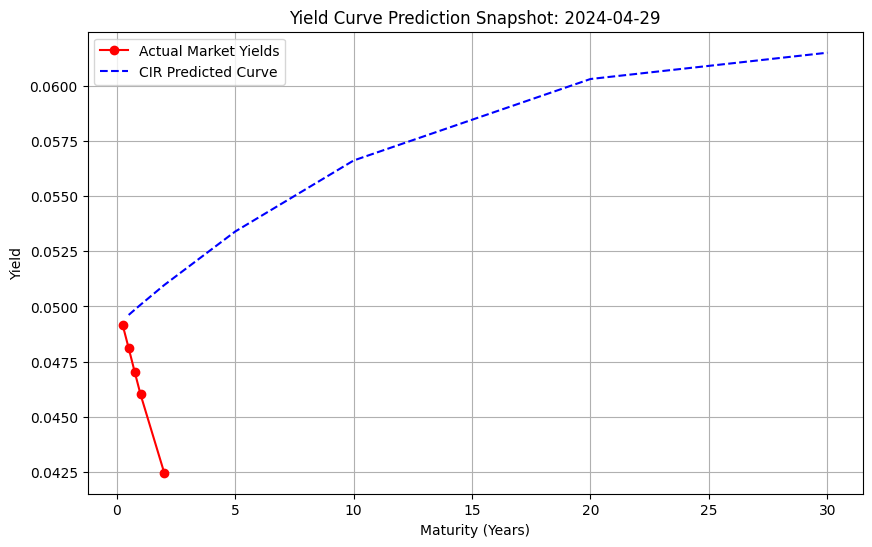

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define the overlapping columns
overlap_map = {
    'ZC050YR': 'ZC050YR_Pred',
    'ZC075YR': 'ZC075YR_Pred',
    'ZC100YR': 'ZC100YR_Pred',
    'ZC200YR': 'ZC200YR_Pred'
}

metrics = []

for market_col, pred_col in overlap_map.items():
    actual = test_df[market_col].values
    predicted = prediction_df[pred_col].values

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    metrics.append({
        'Tenor': market_col,
        'MAE': mae,
        'RMSE': rmse
    })

metrics_df = pd.DataFrame(metrics)
print("--- Out-of-Sample Performance Metrics ---")
display(metrics_df)

# Visualization: Snapshot of the Yield Curve fit
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Safely get the first row index/date
snapshot_date = test_df.index[0]

# Actual market curve (available tenors)
market_tenors = [0.25, 0.5, 0.75, 1.0, 2.0]
# Use .loc for test_df since it has the Date index
market_yields = test_df.loc[snapshot_date, ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']].values
plt.plot(market_tenors, market_yields, 'ro-', label='Actual Market Yields')

# Predicted curve
# Use .iloc[0] for prediction_df since it uses numbered rows, and drop the 'Date' column so it only plots numbers
pred_vals = prediction_df.drop(columns=['Date'], errors='ignore').iloc[0].values
plt.plot(tau_array, pred_vals, 'b--', label='CIR Predicted Curve')

# Format the title safely whether snapshot_date is a Timestamp or string
date_str = snapshot_date.date() if hasattr(snapshot_date, 'date') else snapshot_date
plt.title(f'Yield Curve Prediction Snapshot: {date_str}')

plt.xlabel('Maturity (Years)')
plt.ylabel('Yield')
plt.legend()
plt.grid(True)
plt.show()

###Calculating R2 score

In [ ]:
from sklearn.metrics import r2_score

# Calculate R2 for each overlapping tenor
r2_results = []
for market_col, pred_col in overlap_map.items():
    r2 = r2_score(test_df[market_col], prediction_df[pred_col])
    r2_results.append({'Tenor': market_col, 'R2_Score': r2})

r2_df = pd.DataFrame(r2_results)
print("--- R-Squared Scores per Tenor ---")
display(r2_df)

# Calculate Global Metrics across all overlapping data points
all_actual = []
all_pred = []
for market_col, pred_col in overlap_map.items():
    all_actual.extend(test_df[market_col].values)
    all_pred.extend(prediction_df[pred_col].values)

print("\n--- Global Out-of-Sample Summary ---")
# print(f"Global MAE:  {mean_absolute_error(all_actual, all_pred):.6f}")
# print(f"Global RMSE: {np.sqrt(mean_squared_error(all_actual, all_pred)):.6f}")
print(f"Global R2:   {r2_score(all_actual, all_pred):.6f}")

--- R-Squared Scores per Tenor ---


,Tenor,R2_Score
0,ZC050YR,0.971590
1,ZC075YR,0.900647
2,ZC100YR,0.766329
3,ZC200YR,-0.606827



--- Global Out-of-Sample Summary ---
Global R2:   0.712502


## Improving The Model By Using The 3-Factor CIR Model

### The Theory
The main idea is that interest rates across different tenors are highly correlated—they tend to move together.

Principal Component Analysis (PCA) is a statistical technique used to reduce dimensionality. It transforms the highly correlated yield data into a smaller set of uncorrelated variables called **Principal Components (PCs)**, while retaining almost all the original variance (information) of the dataset.

### The Mathematics & Interpretation
PCA computes the eigenvalues and eigenvectors of the yield covariance matrix. In the context of yield curves, the first three principal components predictably map to specific macroeconomic behaviors:

1. **Factor 1 (Level / Shift):** Represents a parallel shift in the yield curve. If the central bank raises the baseline interest rate, all maturities shift upward roughly equally.
2. **Factor 2 (Slope / Twist):** Represents the steepening or flattening of the curve. This is driven by long-term economic outlooks versus short-term liquidity.
3. **Factor 3 (Curvature / Bow):** Represents the bowing of the curve, often caused by medium-term volatility or specific market interventions.

These three components alone are sufficient to explain the vast majority (typically >95%) of all historical yield curve movements.

---

## Phase 2: The 3-Factor CIR Framework

### The Theory

We assume the observable short rate $r_t$ is actually composed of three unobservable, independent "latent states":

$$r_t = x_{1,t} + x_{2,t} + x_{3,t}$$

Each state $x_i$ acts as a distinct engine driving one of the PCA factors (Level, Slope, Curvature), and each follows its own independent square-root diffusion process:

$$dx_{i,t} = \kappa_i(\theta_i - x_{i,t})dt + \sigma_i\sqrt{x_{i,t}}dW_{i,t}$$

### The Mathematics of Bond Pricing
Because the three processes are independent, the math simplifies beautifully. The price of a bond in a multi-factor model is just the product of the individual bond prices implied by each factor.

When converted to continuously compounded yields, the math becomes additive (the "affine" property). The total yield $y(t, \tau)$ for any maturity $\tau$ is the sum of the yields generated by the three independent factors:

$$y(t, \tau) = \sum_{i=1}^3 \left( \frac{B_i(\tau)x_{i,t} - \ln A_i(\tau)}{\tau} \right)$$

Where $A_i(\tau)$ and $B_i(\tau)$ are the standard deterministic CIR functions calculated using the specific parameters $(\kappa_i, \theta_i, \sigma_i)$ for that factor.

---

## Phase 3: Optimization and Calibration Logic

The code calibrates these 9 parameters ($3 \times \kappa$, $3 \times \theta$, $3 \times \sigma$) using a specific cross-sectional targeting approach.

### 1. The Target Objective
Instead of fitting day-by-day, the code extracts the **unconditional mean** of the yield curve from the training data (`market = train_df[target_cols].mean().values`). The objective function calculates the Sum of Squared Errors (SSE) between the theoretical yields generated by our 9 parameters and this historical market average.

### 2. The State Split Heuristic
Because the underlying states ($x_1, x_2, x_3$) are unobservable, the code must make an assumption to initialize them. It uses a **static heuristic split** of the current 3-Month rate:
* $x_1$ (Level proxy) $= 60\%$
* $x_2$ (Slope proxy) $= 30\%$
* $x_3$ (Curvature proxy) $= 10\%$

Explained Variance Ratio: [0.96327947 0.02976962 0.00539156]
Total Variance Explained: 0.9984


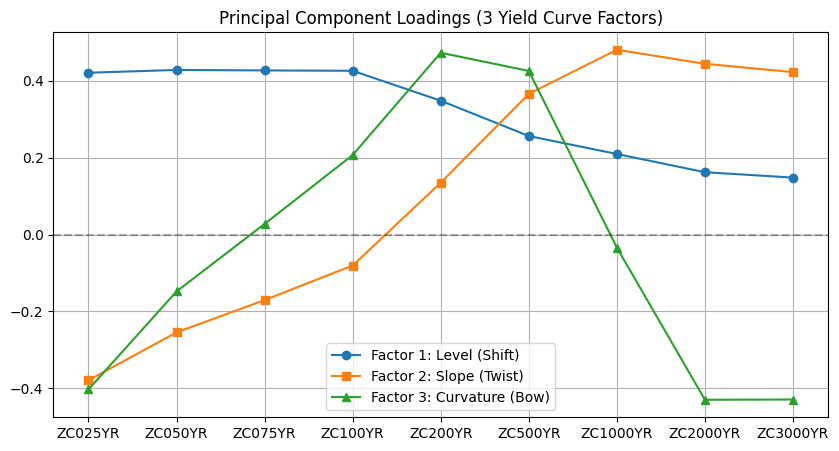

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

try:
    train_df
except NameError:
    train_df = pd.read_csv('/content/train_data.csv')
    train_df.columns = train_df.columns.str.strip()
    train_df['Date'] = pd.to_datetime(train_df['Date'])
    train_df = train_df.set_index('Date').asfreq('D').interpolate(method='linear')

# 1. Identify all yield columns in the training set
yield_cols = [col for col in train_df.columns if col.startswith('ZC')]
train_yields_clean = train_df[yield_cols]

# 2. Apply PCA to identify Level (PC1), Slope (PC2), and Curvature (PC3)
pca = PCA(n_components=3)
pca.fit(train_yields_clean)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {np.sum(pca.explained_variance_ratio_):.4f}")

# Visualize the Factor Loadings
plt.figure(figsize=(10, 5))
plt.plot(yield_cols, pca.components_[0], label='Factor 1: Level (Shift)', marker='o')
plt.plot(yield_cols, pca.components_[1], label='Factor 2: Slope (Twist)', marker='s')
plt.plot(yield_cols, pca.components_[2], label='Factor 3: Curvature (Bow)', marker='^')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Principal Component Loadings (3 Yield Curve Factors)')
plt.legend()
plt.grid(True)
plt.show()

#### Defining the 3-Factor CIR Model
The yield is the sum of three independent CIR processes: $y(t, \tau) = y_1(t, \tau) + y_2(t, \tau) + y_3(t, \tau)$. We will use Differential Evolution to calibrate 9 parameters (3 for each factor: $\kappa, \theta, \sigma$) to optimize the cross-sectional curve fit against target tenors.

In [ ]:
from scipy.optimize import differential_evolution
import numpy as np

def three_factor_cir_obj(params):
    # Unpack 9 parameters for 3 factors
    k1, q1, s1, k2, q2, s2, k3, q3, s3 = params

    # Cross-sectional targets from training data (means)
    tenors = np.array([0.25, 0.5, 0.75, 1.0, 2.0])
    target_cols = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']
    market = train_df[target_cols].mean().values

    # 3-Factor split initialization (e.g., 60% Level, 30% Slope, 10% Curvature)
    r0_1 = market[0] * 0.60
    r0_2 = market[0] * 0.30
    r0_3 = market[0] * 0.10

    def cir_yield_formula(r0, t, kappa, theta, sigma):
        gamma = np.sqrt(kappa**2 + 2 * sigma**2)
        exp_g_t = np.exp(gamma * t)
        denom = 2 * gamma + (kappa + gamma) * (exp_g_t - 1)
        B = (2 * (exp_g_t - 1)) / denom
        A = ((2 * gamma * np.exp((kappa + gamma) * t / 2)) / denom) ** (2 * kappa * theta / sigma**2)
        return (B * r0 - np.log(A)) / t

    y1 = cir_yield_formula(r0_1, tenors, k1, q1, s1)
    y2 = cir_yield_formula(r0_2, tenors, k2, q2, s2)
    y3 = cir_yield_formula(r0_3, tenors, k3, q3, s3)

    # Sum the 3 factors and calculate error against market
    return np.sum((y1 + y2 + y3 - market)**2)

# Bounds for 9 parameters (3 sets of k, q, s)
bounds_3f = [(1e-3, 2.0), (1e-3, 0.1), (1e-3, 0.1)] * 3

print("--- Starting 3-Factor Calibration ---")
res_3f = differential_evolution(three_factor_cir_obj, bounds_3f, strategy='best1bin', popsize=15, seed=42)

if res_3f.success:
    p = res_3f.x
    print(f"Optimized Factor 1 (Level):     k={p[0]:.4f}, q={p[1]:.4f}, s={p[2]:.4f}")
    print(f"Optimized Factor 2 (Slope):     k={p[3]:.4f}, q={p[4]:.4f}, s={p[5]:.4f}")
    print(f"Optimized Factor 3 (Curvature): k={p[6]:.4f}, q={p[7]:.4f}, s={p[8]:.4f}")
else:
    print("3-Factor Calibration Failed.")

--- Starting 3-Factor Calibration ---
Optimized Factor 1 (Level):     k=0.4096, q=0.0010, s=0.0805
Optimized Factor 2 (Slope):     k=0.3963, q=0.0011, s=0.0950
Optimized Factor 3 (Curvature): k=1.6439, q=0.0098, s=0.0731


### 3-Factor Model Evaluation
Now we apply the optimized 3-factor parameters to the test set to evaluate the final out-of-sample performance across all target tenors using the $R^2$ score.


In [ ]:
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# --- USER INPUT ---
test_file_name = '/content/test_data.csv' # CHANGE THIS ACCORDING TO THE INPUT FILE
# ------------------

# Extract parameters from our 3-factor calibration (p)
k1, q1, s1, k2, q2, s2, k3, q3, s3 = p
r0_3m_test = test_df['ZC025YR'].values

# Factor split used in calibration
r0_1_test = r0_3m_test * 0.60
r0_2_test = r0_3m_test * 0.30
r0_3_test = r0_3m_test * 0.10

# CIR formula
def cir_yield_eval(r0, t, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_g_t = np.exp(gamma * t)
    denom = 2 * gamma + (kappa + gamma) * (exp_g_t - 1)
    B = (2 * (exp_g_t - 1)) / denom
    A = ((2 * gamma * np.exp((kappa + gamma) * t / 2)) / denom) ** (2 * kappa * theta / sigma**2)
    return (B[None, :] * r0[:, None] - np.log(A)[None, :]) / t[None, :]

test_tenors = np.array([0.5, 0.75, 1.0, 2.0]) # Tenors to predict
y1_test = cir_yield_eval(r0_1_test, test_tenors, k1, q1, s1)
y2_test = cir_yield_eval(r0_2_test, test_tenors, k2, q2, s2)
y3_test = cir_yield_eval(r0_3_test, test_tenors, k3, q3, s3)

# Combined 3-Factor Prediction
pred_3f = y1_test + y2_test + y3_test

# Create a DataFrame for predictions
prediction_3f_df = pd.DataFrame(pred_3f, columns=[f'ZC{int(t*100)}YR' for t in test_tenors])
prediction_3f_df.insert(0, 'Date', test_df.index)

# saving prediction file for _3M dataset
if "3M.csv" in test_file_name:
    print(f"Generating 3-Factor CIR predictions for {test_file_name} (no R2 calculation as per instructions).")
    output_filename = 'submission_3Factor_3M_predictions.csv'
    prediction_3f_df.to_csv(output_filename, index=False)
    print(f"Predictions saved to '{output_filename}'")
else:
    market_cols = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']
    actual_3f = test_df[market_cols].values

    print('--- 3-Factor CIR Out-of-Sample R2 Scores ---')
    for i, col in enumerate(market_cols):
        score = r2_score(actual_3f[:, i], pred_3f[:, i])
        print(f'{col}: {score:.4f}')

    global_score_3f = r2_score(actual_3f.flatten(), pred_3f.flatten())
    print(f'\nFINAL 3-FACTOR GLOBAL R2: {global_score_3f:.4f}')

    output_filename = 'submission_3Factor_predictions.csv'
    prediction_3f_df.to_csv(output_filename, index=False)
    print(f"Predictions saved to '{output_filename}'")

--- 3-Factor CIR Out-of-Sample R2 Scores ---
ZC050YR: 0.9897
ZC075YR: 0.9789
ZC100YR: 0.9571
ZC200YR: 0.6526

FINAL 3-FACTOR GLOBAL R2: 0.9384
Predictions saved to 'submission_3Factor_predictions.csv'
